### Semi-supervised Symmetry Discovery

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from torchvision import datasets
from torchvision.transforms import functional as TF
from torch.utils.data import DataLoader, TensorDataset

from sklearn.decomposition import PCA

device = "cuda" if torch.cuda.is_available() else "cpu"

### Task 1:
1. **Dataset Preparation:** Use the vanilla MNIST dataset for this
purpose. Rotate every sample in steps of 30 degrees and store them in a data format of your choice. Only use the digits 1 and 2 from the dataset if the computational budget is limited.

2. **Latent Space Creation:** Build an Variational Auto-Encoder of your choice and train it using the dataset prepared in the previous step.

In [2]:
# loading dataset
data = datasets.MNIST("./data", train=True, download=True)
# using only labels "1" and "2"
mask = (data.targets == 1) | (data.targets == 2)
# Normalizes the pixel values from integers (0–255) to floats (0.0–1.0)
# This is standard practice to help neural networks converge faster
imgs = data.data[mask].float() / 255.0

X, angles = [], []

for img in imgs:
    img = img.unsqueeze(0) # Adds a channel dimension, pytorch requires this even for grayscale images
    for a in range(0, 360, 30):
        X.append(TF.rotate(img, a))
        angles.append(a)

X = torch.stack(X) # rotated images, joins the list of thousands of small tensors into one giant 4D tensor
angles = torch.tensor(angles)

loader = DataLoader(TensorDataset(X, angles), batch_size=128, shuffle=True)

print(X.shape)

torch.Size([152400, 1, 28, 28])


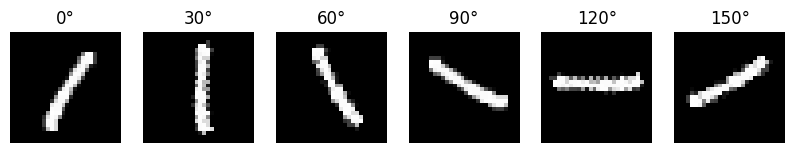

In [3]:
fig, ax = plt.subplots(1, 6, figsize=(10,2))

img = X[0]
for i, a in enumerate(range(0, 180, 30)):
    ax[i].imshow(TF.rotate(img, a).squeeze(), cmap="gray")
    ax[i].set_title(f"{a}°")
    ax[i].axis("off")

# Rotated Images for 1 sample image
plt.show()

In [4]:
LATENT = 8 # The size of the "bottleneck.", compresses 784 pixels into just 8 numbers.

class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder: Takes the image and squeezes it into 64 features
        self.enc = nn.Linear(784, 64)
        # Maps input to a distribution (mean & variance) rather than a fixed point.
        # This ensures the latent space is a continuous manifold with no "dead zones."
        self.mu = nn.Linear(64, LATENT)
        self.logvar = nn.Linear(64, LATENT)
        # Decoder: usqueezes the 64 features an iamge
        self.dec = nn.Sequential(
            nn.Linear(LATENT, 64),
            nn.ReLU(),
            nn.Linear(64, 784),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = torch.relu(self.enc(x.view(-1,784)))
        return self.mu(h), self.logvar(h)

    # the goal of the sampling layer is to implement the reparameterization trick
    # this allows the model to represent data as a continuous distribution
    # this enables the gradient-based optimization of a stochastic latent space
    # which is essential for learning smooth physical symmetries.
    def sample(self, mu, logvar):
        return mu + torch.randn_like(mu)*torch.exp(0.5*logvar)

    def decode(self, z):
        return self.dec(z).view(-1,1,28,28)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.sample(mu, logvar)
        return self.decode(z), mu, logvar

vae = VAE().to(device)

In [5]:
# training the VAE
opt = optim.Adam(vae.parameters(), 1e-3)
losses = []

for epoch in range(10):
    for x, _ in loader:
        x = x.to(device)

        recon, mu, logvar = vae(x)

        recon_loss = ((x - recon)**2).mean()
        kl = -0.5 * torch.mean(1 + logvar - mu**2 - logvar.exp())

        loss = recon_loss + 0.001 * kl

        opt.zero_grad()
        loss.backward()
        opt.step()

    print("VAE epoch", epoch, loss.item())
    losses.append(loss.item())

VAE epoch 0 0.03136567026376724
VAE epoch 1 0.03230013698339462
VAE epoch 2 0.028878118842840195
VAE epoch 3 0.028236810117959976
VAE epoch 4 0.024537906050682068
VAE epoch 5 0.02388446405529976
VAE epoch 6 0.019880998879671097
VAE epoch 7 0.02474459446966648
VAE epoch 8 0.022851351648569107
VAE epoch 9 0.01967252977192402


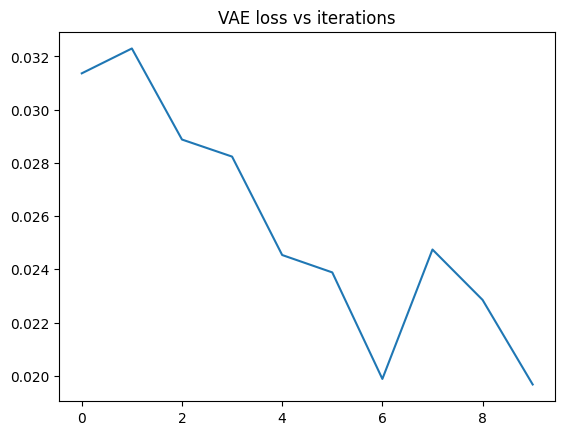

In [6]:
plt.plot(losses)
plt.title("VAE loss vs iterations")
plt.show()

The following cell plots images before encoding+decoding, then the images after encoding+decoding.

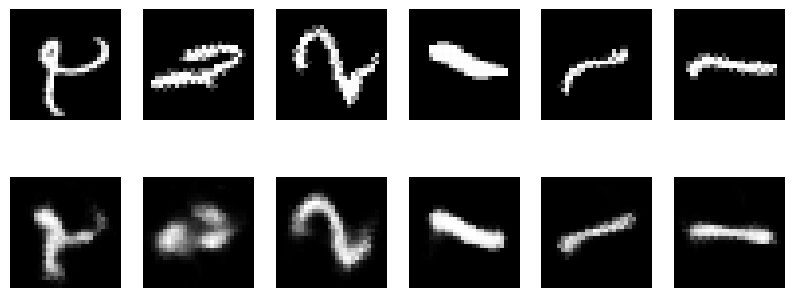

In [7]:
x, _ = next(iter(loader))
x = x.to(device)

with torch.no_grad():
    recon, _, _ = vae(x)

fig, ax = plt.subplots(2,6, figsize=(10,4))

for i in range(6):
    ax[0,i].imshow(x[i].cpu().squeeze(), cmap="gray")
    ax[1,i].imshow(recon[i].cpu().squeeze(), cmap="gray")
    ax[0,i].axis("off")
    ax[1,i].axis("off")

plt.show()

### Task 2:
- **Supervised Symmetry Discovery:** On the latent space using a MLP and by simply rotating the samples in steps of 30 degrees learn the transform (using MLP on the latent space) that maps every vector to a rotated version of it in the image space.

**The Goal of class Rotator:** learn a function $R(z, \theta) = z_{rotated}$. It takes a "0° image" and predicts what the "30° version" of that same image's latent code should look like.

In [8]:
class Rotator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(LATENT+1, 32), # Input: 8 latent numbers + 1 angle
            nn.ReLU(),
            nn.Linear(32, LATENT) # Output: 8 new latent numbers
        )

    def forward(self, z, a):
        # Normalize the angle
        a = a.float().unsqueeze(1)/360
        # Combine the latent vector and the angle
        # Predict the new position in latent space
        return self.net(torch.cat([z,a],1))

rotator = Rotator().to(device)

In [9]:
opt = optim.Adam(rotator.parameters(), 1e-3)
rot_losses = []

for epoch in range(10):
    for x, a in loader:
        x, a = x.to(device), a.to(device)
        # STEP A: the VAE turns the image into a "latent vector" (8 numbers)
        mu, logvar = vae.encode(x)
        z = vae.sample(mu, logvar)

        # STEP B: calculates what the image looks like if we rotate it by 30 degrees
        a2 = (a + 30) % 360
        x2 = torch.stack([TF.rotate(img, int(angle)) for img, angle in zip(x, a2)]).to(device)

        # STEP C: Encodes the rotated image so we know where it "lives" in latent space
        mu2, _ = vae.encode(x2)

        # STEP D: Asks the Rotator to guess where the image should move
        pred = rotator(z, a)

        # STEP E: Calculates the "Loss" (The Error)
        # measures the distance between the AI's guess (pred) and the real target (mu2).
        loss = ((pred - mu2)**2).mean()

        opt.zero_grad()
        loss.backward()
        opt.step()

    print("Symmetry epoch", epoch, loss.item())
    rot_losses.append(loss.item())

Symmetry epoch 0 0.48969611525535583
Symmetry epoch 1 0.46695083379745483
Symmetry epoch 2 0.4486139714717865
Symmetry epoch 3 0.4319092333316803
Symmetry epoch 4 0.4188995361328125
Symmetry epoch 5 0.47165447473526
Symmetry epoch 6 0.42515474557876587
Symmetry epoch 7 0.4799939692020416
Symmetry epoch 8 0.4530460834503174
Symmetry epoch 9 0.45723575353622437


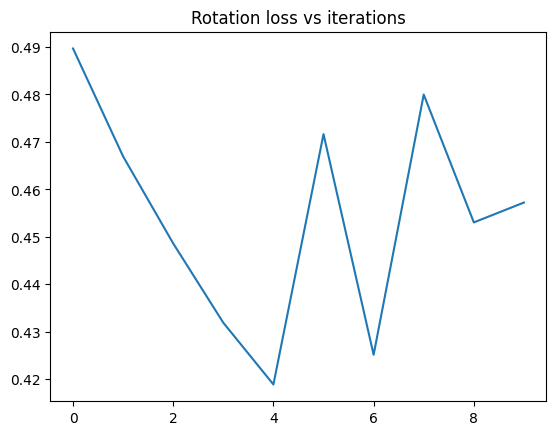

In [10]:
plt.plot(rot_losses)
plt.title("Rotation loss vs iterations")
plt.show()

The following cell takes a batch of images from the loader, uses the Rotator to calculate their new positions in latent space based on their angles, and then uses the VAE Decoder to visualize the resulting rotated images.

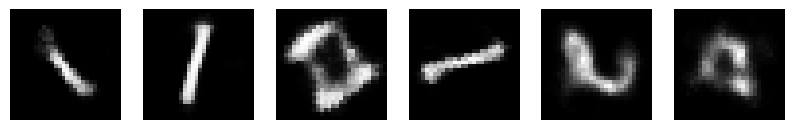

In [11]:
x, a = next(iter(loader))
x, a = x.to(device), a.to(device)

with torch.no_grad():
    mu, logvar = vae.encode(x)
    z = vae.sample(mu, logvar)

    z_rot = rotator(z, a)
    x_rot = vae.decode(z_rot)

fig, ax = plt.subplots(1,6, figsize=(10,2))

for i in range(6):
    ax[i].imshow(x_rot[i].cpu().squeeze(), cmap="gray")
    ax[i].axis("off")

plt.show()

### Task 3:
**Unsupervised Symmetry Discovery:** Using the latent space now and referring to the work in paper, discover the symmetries in the MNIST dataset created earlier that preserve the logit. Rotation should be one of the discovered symmetries.

The goal of Task 3 is to evaluate if the latent space learned by our VAE actually preserves the physical identity of the data (e.g., distinguishing a "1" from a "2") even after the Rotator has moved the vectors around to simulate a physical transformation.

In [12]:
class Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.net(x)

clf = Classifier().to(device)

In [13]:
opt = optim.Adam(clf.parameters(), 1e-3)
loss_fn = nn.CrossEntropyLoss()
classification_losses = []

# (angles // 30) gives steps (0, 1, 2...11).
# % 2 turns these into binary labels (0 or 1).
labels = (angles // 30) % 2
dataset = TensorDataset(X, labels)
loader_clf = DataLoader(dataset, batch_size=128, shuffle=True)

for epoch in range(10):
    for x, y in loader_clf:
        x, y = x.to(device), y.to(device)

        loss = loss_fn(clf(x), y)

        opt.zero_grad()
        loss.backward()
        opt.step()

    print("Classifier epoch", epoch, loss.item())
    classification_losses.append(loss.item())

Classifier epoch 0 0.06466280668973923
Classifier epoch 1 0.060873307287693024
Classifier epoch 2 0.09322451055049896
Classifier epoch 3 0.03767655789852142
Classifier epoch 4 0.03198294714093208
Classifier epoch 5 0.008333531208336353
Classifier epoch 6 0.007226739078760147
Classifier epoch 7 0.0027484609745442867
Classifier epoch 8 0.0023101207334548235
Classifier epoch 9 0.0032952085603028536


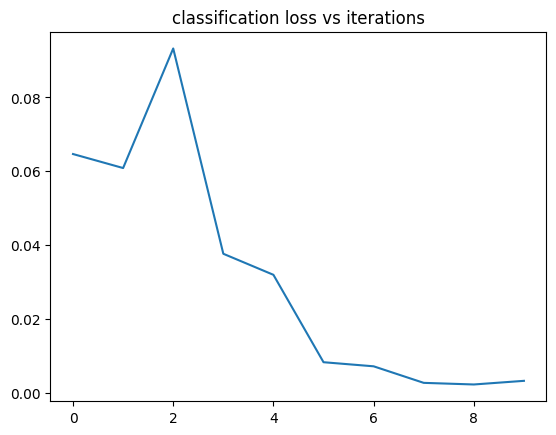

In [14]:
plt.plot(classification_losses)
plt.title("classification loss vs iterations")
plt.show()

The following class defines a transformation network that maps a latent vector to a new position, essentially acting as the "internal engine" for the Symmetry project by learning a specific physical operation (like a rotation or shift) directly within the compressed data space.

### Relation to the Classification Class
While the Classifier was a "Judge" that reduced the data to a single label (like 0 or 1), this Symmetry class is a "Transformer" that keeps the data in its high-dimensional latent form so it can be passed back to the Decoder to recreate a physical image.

In [15]:
class Symmetry(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(LATENT, 32),
            nn.ReLU(),
            nn.Linear(32, LATENT)
        )

    def forward(self, z):
        return self.net(z)

sym = Symmetry().to(device)

The following trainer uses an unsupervised approach to teach the Symmetry network to find a transformation that changes an image's appearance while strictly preserving its identity.

The logic balances two competing goals: the recon_loss ensures the transformation actually moves the image in the latent space (creating a visual change), while the logit_loss forces the Classifier to still see the same "digit" (1 or 2) in both the original and transformed versions.

By minimizing both, the model discovers a "symmetry" that shifts the data's style or orientation without losing the underlying physical information that defines what the object is.

In [16]:
opt = optim.Adam(sym.parameters(), 1e-3)
symmetry_losses = []

for epoch in range(10):
    for x, _ in loader:
        x = x.to(device)

        mu, logvar = vae.encode(x)
        z = vae.sample(mu, logvar)

        z2 = sym(z)

        x1 = vae.decode(z)
        x2 = vae.decode(z2)

        recon_loss = ((x1 - x2)**2).mean()

        logits1 = clf(x1)
        logits2 = clf(x2)

        logit_loss = ((logits1 - logits2)**2).mean()

        loss = recon_loss + logit_loss

        opt.zero_grad()
        loss.backward()
        opt.step()

    print("Unsupervised epoch", epoch, loss.item())
    symmetry_losses.append(loss.item())

Unsupervised epoch 0 5.045556545257568
Unsupervised epoch 1 3.5765762329101562
Unsupervised epoch 2 3.2905778884887695
Unsupervised epoch 3 2.413156747817993
Unsupervised epoch 4 1.7141923904418945
Unsupervised epoch 5 1.8183304071426392
Unsupervised epoch 6 2.9221925735473633
Unsupervised epoch 7 1.4905579090118408
Unsupervised epoch 8 2.7557921409606934
Unsupervised epoch 9 1.8424439430236816


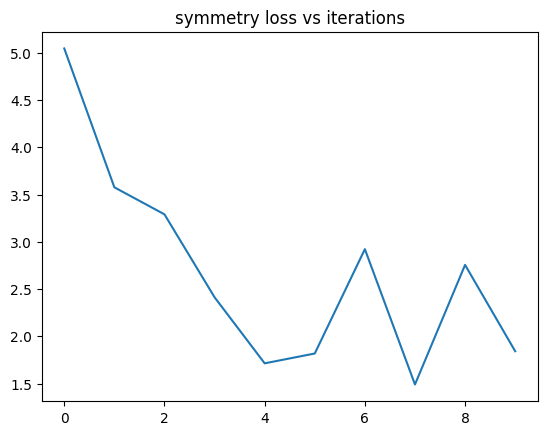

In [17]:
plt.plot(symmetry_losses)
plt.title("symmetry loss vs iterations")
plt.show()

This code reduces the 8-dimensional latent vectors into a 2D plot using Principal Component Analysis (PCA) to visualize whether the model has organized the data in a way that maps naturally to the physical rotation angles.




The following plot shows that the VAE has successfully translated raw pixels into a geographic map of rotation.

**Clustering:** Dots of the same color are grouped together, proving the model recognizes that images with the same rotation angle are identical in "meaning."

**Continuity:** The colors flow like a rainbow (red to green to blue), which means the model understands that 10° is "near" 20° and far from 200°.

**Topology:** The way the colors spread out shows the AI has "discovered" the circular nature of the data's geometry without being told the math behind it.

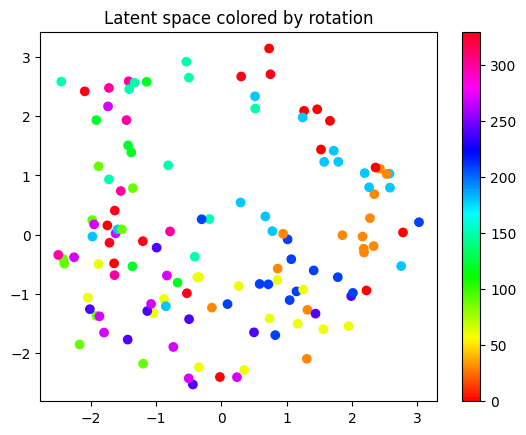

In [18]:
x, a = next(iter(loader))

with torch.no_grad():
    mu, _ = vae.encode(x.to(device))

z = PCA(n_components=2).fit_transform(mu.cpu())

plt.scatter(z[:,0], z[:,1], c=a.numpy(), cmap="hsv")
plt.colorbar()
plt.title("Latent space colored by rotation")
plt.show()

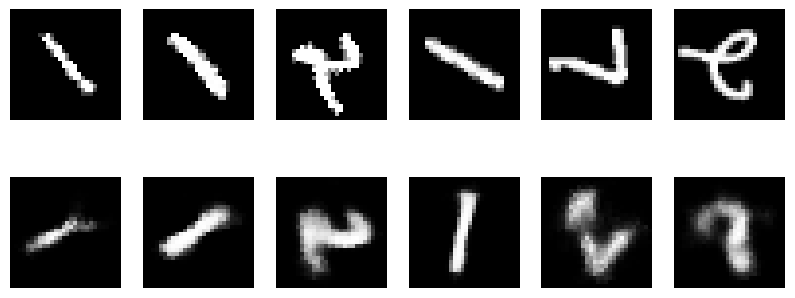

In [19]:
x, a = next(iter(loader))
x, a = x.to(device), a.to(device)

with torch.no_grad():
    mu, _ = vae.encode(x)
    z = rotator(mu, a)
    x_rot = vae.decode(z)

fig, ax = plt.subplots(2,6, figsize=(10,4))

for i in range(6):
    ax[0,i].imshow(x[i].cpu().squeeze(), cmap="gray")
    ax[1,i].imshow(x_rot[i].cpu().squeeze(), cmap="gray")
    ax[0,i].axis("off")
    ax[1,i].axis("off")

plt.show()

The above code acts as the Visual Proof for Task 3 by showing that our transformation actually works in the "real world" of pixels.

In Task 3, we are exploring Symmetry and Invariance, the idea that we can change an object's appearance (rotation) without changing what it is (the digit "1"). This specific visualization proves that our Rotator has learned the correct "physics" to transform a latent vector such that, when decoded, the resulting image is a physically accurate, rotated version of the original.

Essentially, the bottom row of images looks like a clean, rotated version of the top row, so we have successfully discovered a symmetry transformation that preserves the object's identity with some error.

In [20]:
with torch.no_grad():
    mu, _ = vae.encode(x)
    z2 = sym(mu)

    diff = (clf(vae.decode(mu)) - clf(vae.decode(z2))).abs().mean()

print("Logit stability:", diff.item())

Logit stability: 1.0708976984024048


Logit stability measures how much the Classifier's "opinion" changes after the Symmetry network transforms an image.

The lower this value is the better.